## 1. Introduction
### 1.1. Lab overview

In this ungraded lab, you will implement the **reflection pattern** introduced in the lecture video within an agentic workflow that generates data visualizations. A multi-modal LLM will review the first draft chart, identify potential improvements—such as chart type, labels, or color choices—and then rewrite the chart generation code to produce a more effective visualization.

In the video, Andrew presented the following workflow for analyzing coffee sales. You will implement this in code here. The steps that the workflow will carry out are:

1. **Generate an initial version (V1):**
Use a Large Language Model (LLM) to create the first version of the plotting code.

2. **Execute code and create chart:**
Run the generated code and display the resulting chart.

3. **Reflect on the output:**
Evaluate both the code and the chart using an LLM to detect areas for improvement (e.g., clarity, accuracy, design).

4. **Generate and execute improved version (V2):**
Produce a refined version of the plotting code based on reflection insights and render the enhanced chart.

<img src='M2-UGL-2.png'>

### 🎯 1.2. Learning outcome

By the end of this lab, you will have implemented the reflection pattern in code and used it to improve a data visualization.

In [1]:
import re
import json

# Local helper module
import utils

In [2]:
# Use this utils.py function to load the data into a dataframe
df = utils.load_and_prepare_data('coffee_sales.csv')

# Grab a random sample to display
utils.print_html(df.sample(n=5), title="Random Sample of Coffee Sales Data")

date,time,cash_type,card,price,coffee_name,quarter,month,year
2024-10-26,14:07,card,ANON-0000-0000-0818,3.576,Latte,4,10,2024
2024-12-07,12:03,card,ANON-0000-0000-0988,3.086,Americano with Milk,4,12,2024
2024-10-03,15:52,card,ANON-0000-0000-0711,3.576,Cappuccino,4,10,2024
2024-05-19,16:57,card,ANON-0000-0000-0189,3.772,Cappuccino,2,5,2024
2024-09-07,12:47,card,ANON-0000-0000-0141,2.302,Cortado,3,9,2024


In [3]:
def generate_chart_code(instruction: str, model: str, out_path_v1: str) -> str:
    """Generate Python code to make a plot with matplotlib using tag-based wrapping."""

    prompt = f"""
    You are a data visualization expert.

    Return your answer *strictly* in this format:

    <execute_python>
    # valid python code here
    </execute_python>

    Do not add explanations, only the tags and the code.

    The code should create a visualization from a DataFrame 'df' with these columns:
    - date   (datetime64 — already parsed; use df['date'].dt.year, df['date'].dt.month, etc.)
    - time   (string, HH:MM — do NOT concatenate or combine with the date column)
    - cash_type (string: 'card' or 'cash')
    - card (string)
    - price (number)
    - coffee_name (string)
    - quarter (int, 1–4 — already computed, use directly)
    - month  (int, 1–12 — already computed, use directly)
    - year   (int, e.g. 2024 — already computed, use directly)

    User instruction: {instruction}

    Requirements for the code:
    1. Assume the DataFrame is already loaded as 'df'.
    2. Use matplotlib for plotting.
    3. Add clear title, axis labels, and legend if needed.
    4. Save the figure as '{out_path_v1}' with dpi=300.
    5. Do not call plt.show().
    6. Close all plots with plt.close().
    7. Add all necessary import python statements
    8. CRITICAL: 'date' is datetime64 — never use string concatenation on it.
       Filter by year/quarter using the 'year' and 'quarter' integer columns.

    Return ONLY the code wrapped in <execute_python> tags.
    """

    response = utils.get_response(model, prompt)
    return response

In [6]:
# Generate initial code
code_v1 = generate_chart_code(
    instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
    model="gpt-5.6-luna",
    out_path_v1="chart_v1.png"
)

utils.print_html(code_v1, title="LLM output with first draft code")


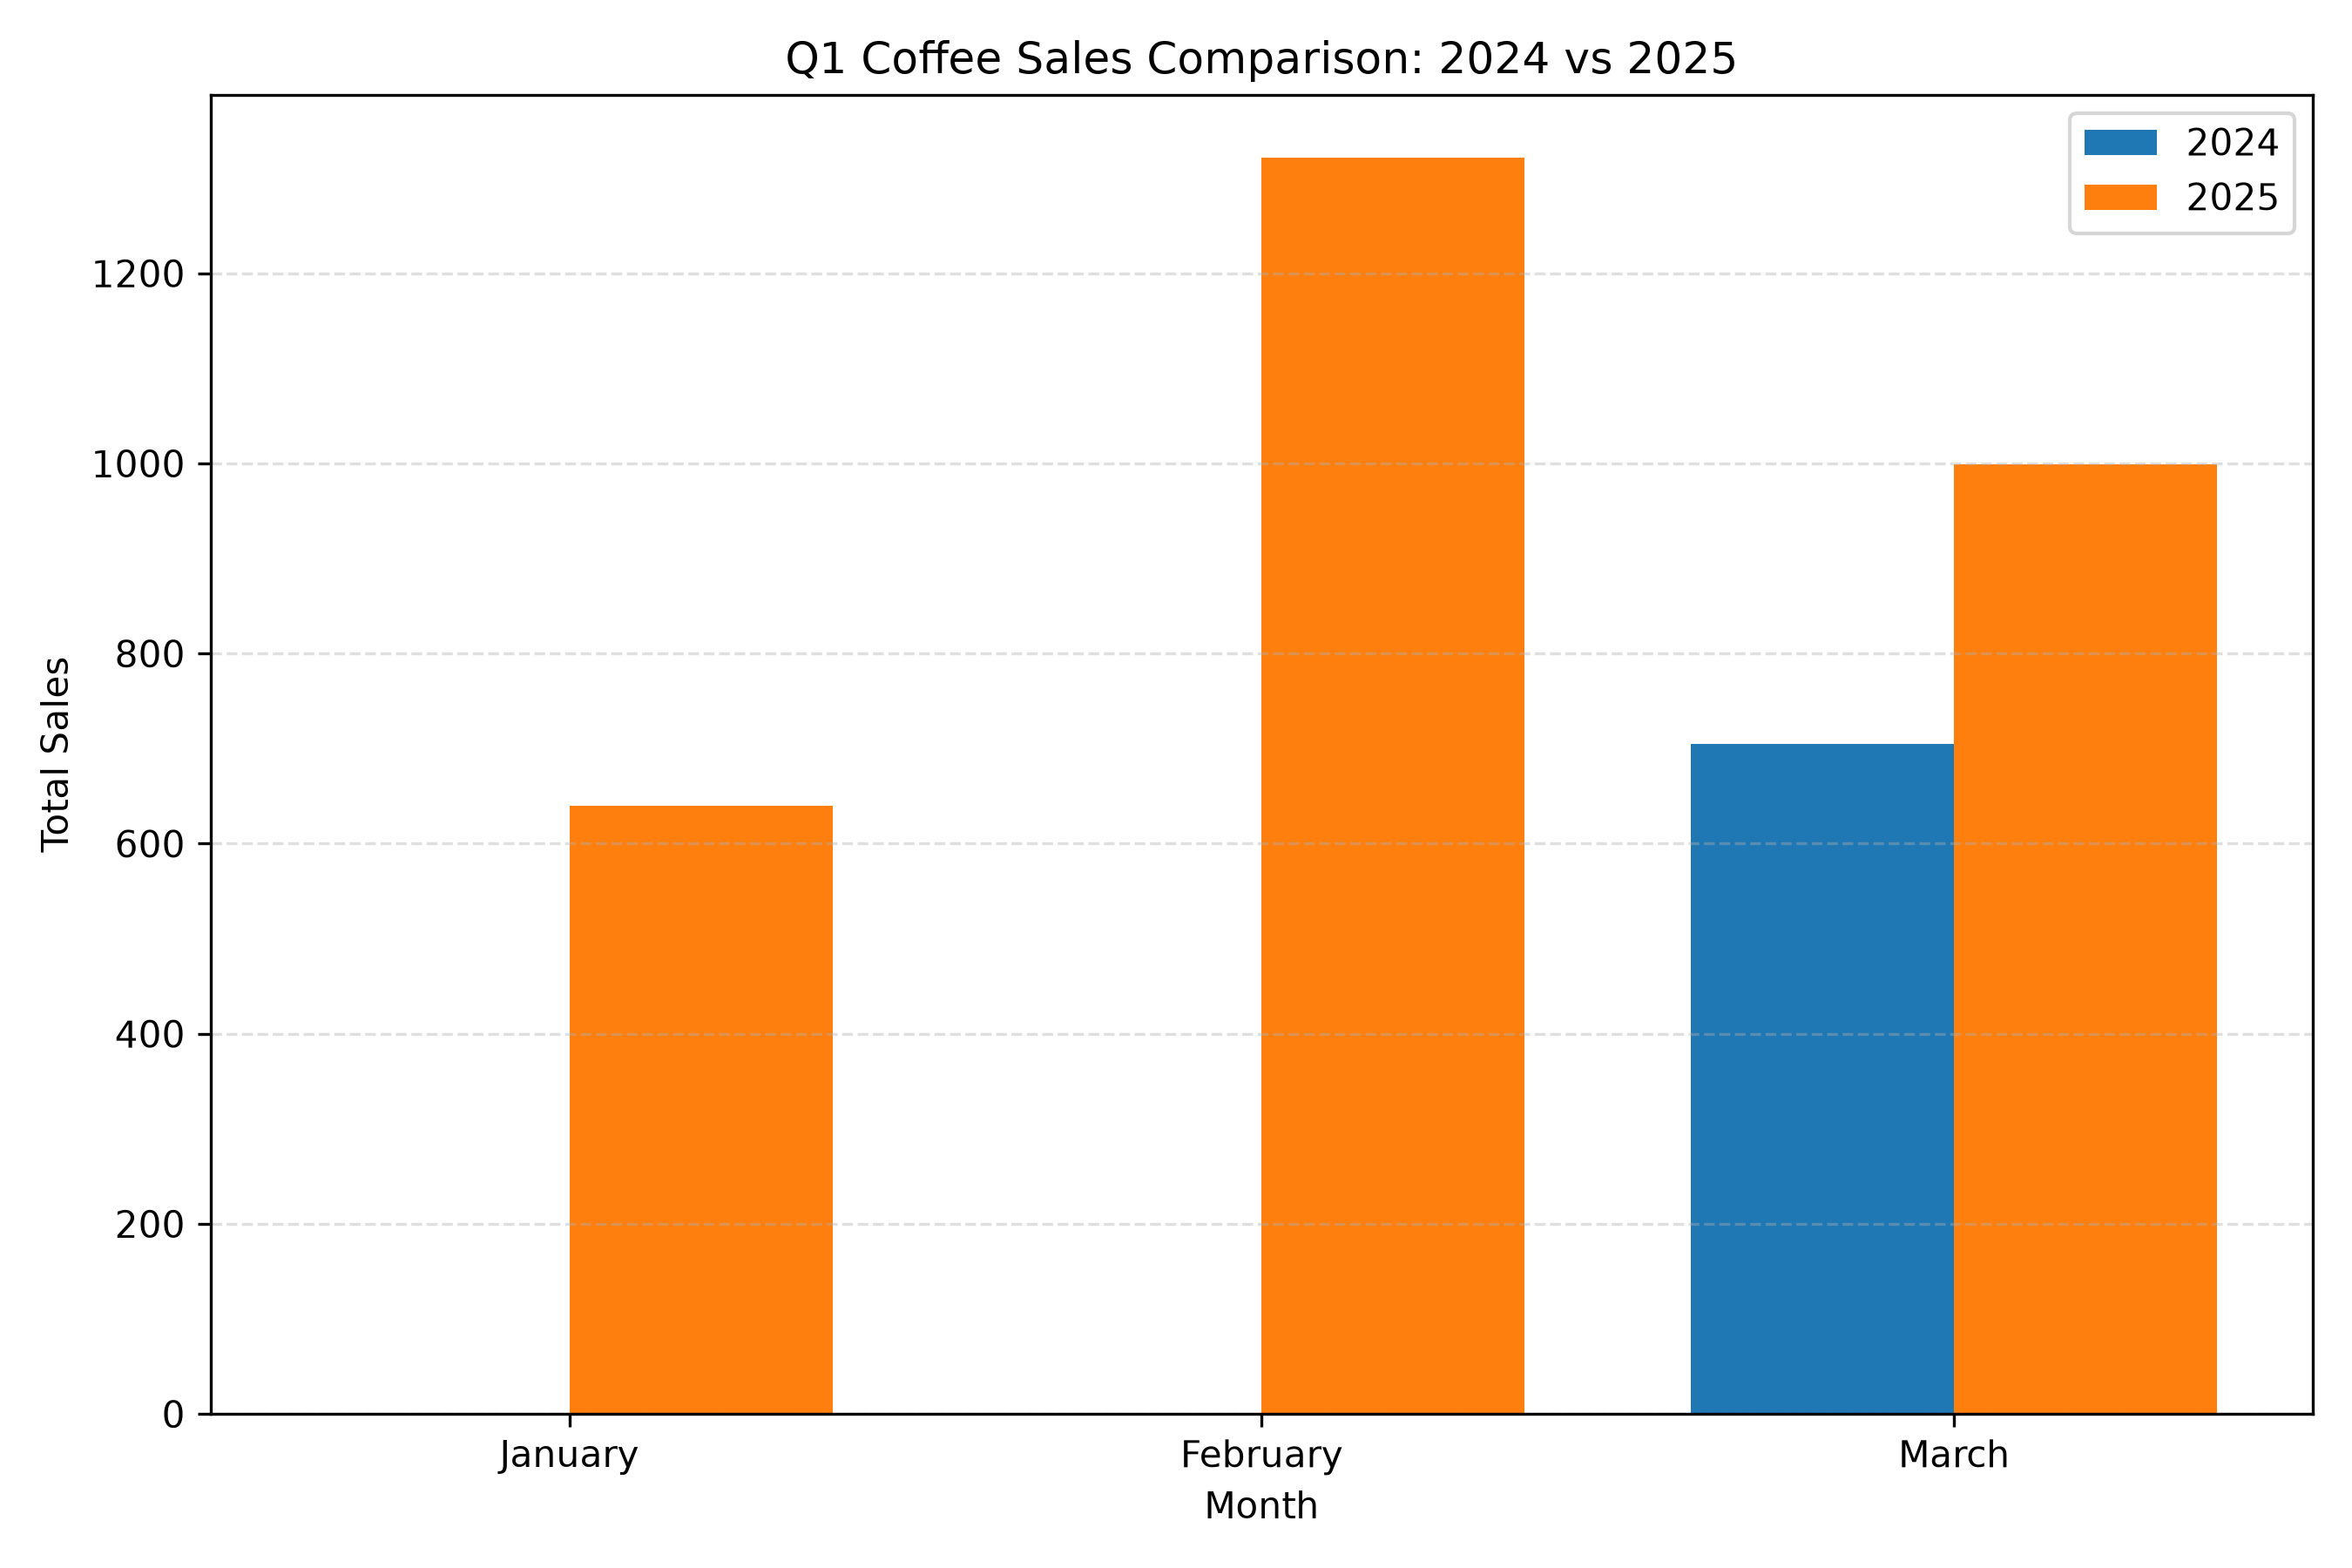

In [7]:
# Get the code within the <execute_python> tags
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
if match:
    initial_code = match.group(1).strip()
    utils.print_html(initial_code, title="Extracted Code to Execute")
    exec_globals = {"df": df}
    exec(initial_code, exec_globals)

# If code run successfully, the file chart_v1.png should have been generated
utils.print_html(
    content="chart_v1.png",
    title="Generated Chart (V1)",
    is_image=True
)

In [8]:
def reflect_on_image_and_regenerate(
        chart_path: str,
        instruction: str,
        model_name: str,
        out_path_v2: str,
        code_v1: str,
) -> tuple[str, str]:
    """
    Critique the chart IMAGE and the original code against the instruction,
    then return refined matplotlib code.
    Returns (feedback, refined_code_with_tags).
    Works with OpenAI vision-capable models (e.g. gpt-4o-mini, gpt-4o, gpt-4.1, o4-mini).
    """
    media_type, b64 = utils.encode_image_b64(chart_path)

    prompt = f"""
    You are a data visualization expert.
    Your task: critique the attached chart and the original code against the given instruction,
    then return improved matplotlib code.

    Original code (for context):
    {code_v1}

    OUTPUT FORMAT (STRICT):
    1) First line: a valid JSON object with ONLY the "feedback" field.
    Example: {{"feedback": "The legend is unclear and the axis labels overlap."}}

    2) After a newline, output ONLY the refined Python code wrapped in:
    <execute_python>
    ...
    </execute_python>

    3) Import all necessary libraries in the code. Don't assume any imports from the original code.

    HARD CONSTRAINTS:
    - Do NOT include Markdown, backticks, or any extra prose outside the two parts above.
    - Use pandas/matplotlib only (no seaborn).
    - Assume df already exists; do not read from files.
    - Save to '{out_path_v2}' with dpi=300.
    - Always call plt.close() at the end (no plt.show()).
    - Include all necessary import statements.

    IMPORTANT: The 'date' column is already a pandas datetime64 type.
    - Do NOT concatenate 'date' with 'time' using string operations.
    - To filter by year/quarter, use: df[df['year'] == 2024] or df['date'].dt.year == 2024
    - The 'quarter' and 'year' columns already exist as integers; use them directly.

    Schema (columns available in df):
    - date   (datetime64 — already parsed; use df['date'].dt.year, etc.)
    - time   (string, HH:MM — do NOT concatenate with date)
    - cash_type (string: 'card' or 'cash')
    - card   (string)
    - price  (float)
    - coffee_name (string)
    - quarter (int, 1–4)
    - month  (int, 1–12)
    - year   (int)

    CRITICAL TYPE RULE: 'date' is already datetime64.
    - NEVER do: df['date'] + ' ' + df['time']  ← this will crash
    - ALWAYS filter by year/quarter using the integer columns: df[df['year'] == 2024]

    Instruction:
    {instruction}
    """

    # Send the chart image + prompt to the reflection model
    content = utils.image_openai_call(model_name, prompt, media_type, b64)

    # --- Parse ONLY the first JSON line (feedback) ---
    lines = content.strip().splitlines()
    json_line = lines[0].strip() if lines else ""

    try:
        obj = json.loads(json_line)
    except Exception as e:
        # Fallback: try to capture the first {...} in all the content
        m_json = re.search(r"\{.*?\}", content, flags=re.DOTALL)
        if m_json:
            try:
                obj = json.loads(m_json.group(0))
            except Exception as e2:
                obj = {"feedback": f"Failed to parse JSON: {e2}", "refined_code": ""}
        else:
            obj = {"feedback": f"Failed to find JSON: {e}", "refined_code": ""}

    # --- Extract refined code from <execute_python>...</execute_python> ---
    m_code = re.search(r"<execute_python>([\s\S]*?)</execute_python>", content)
    refined_code_body = m_code.group(1).strip() if m_code else ""
    refined_code = utils.ensure_execute_python_tags(refined_code_body)

    feedback = str(obj.get("feedback", "")).strip()
    return feedback, refined_code



In [9]:
# Generate feedback alongside reflected code
feedback, code_v2 = reflect_on_image_and_regenerate(
    chart_path="chart_v1.png",
    instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
    model_name="gpt-5.6-terra",
    out_path_v2="chart_v2.png",
    code_v1=code_v1,  # pass in the original code for context
)

utils.print_html(feedback, title="Feedback on V1 Chart")
utils.print_html(code_v2, title="Regenerated Code Output (V2)")


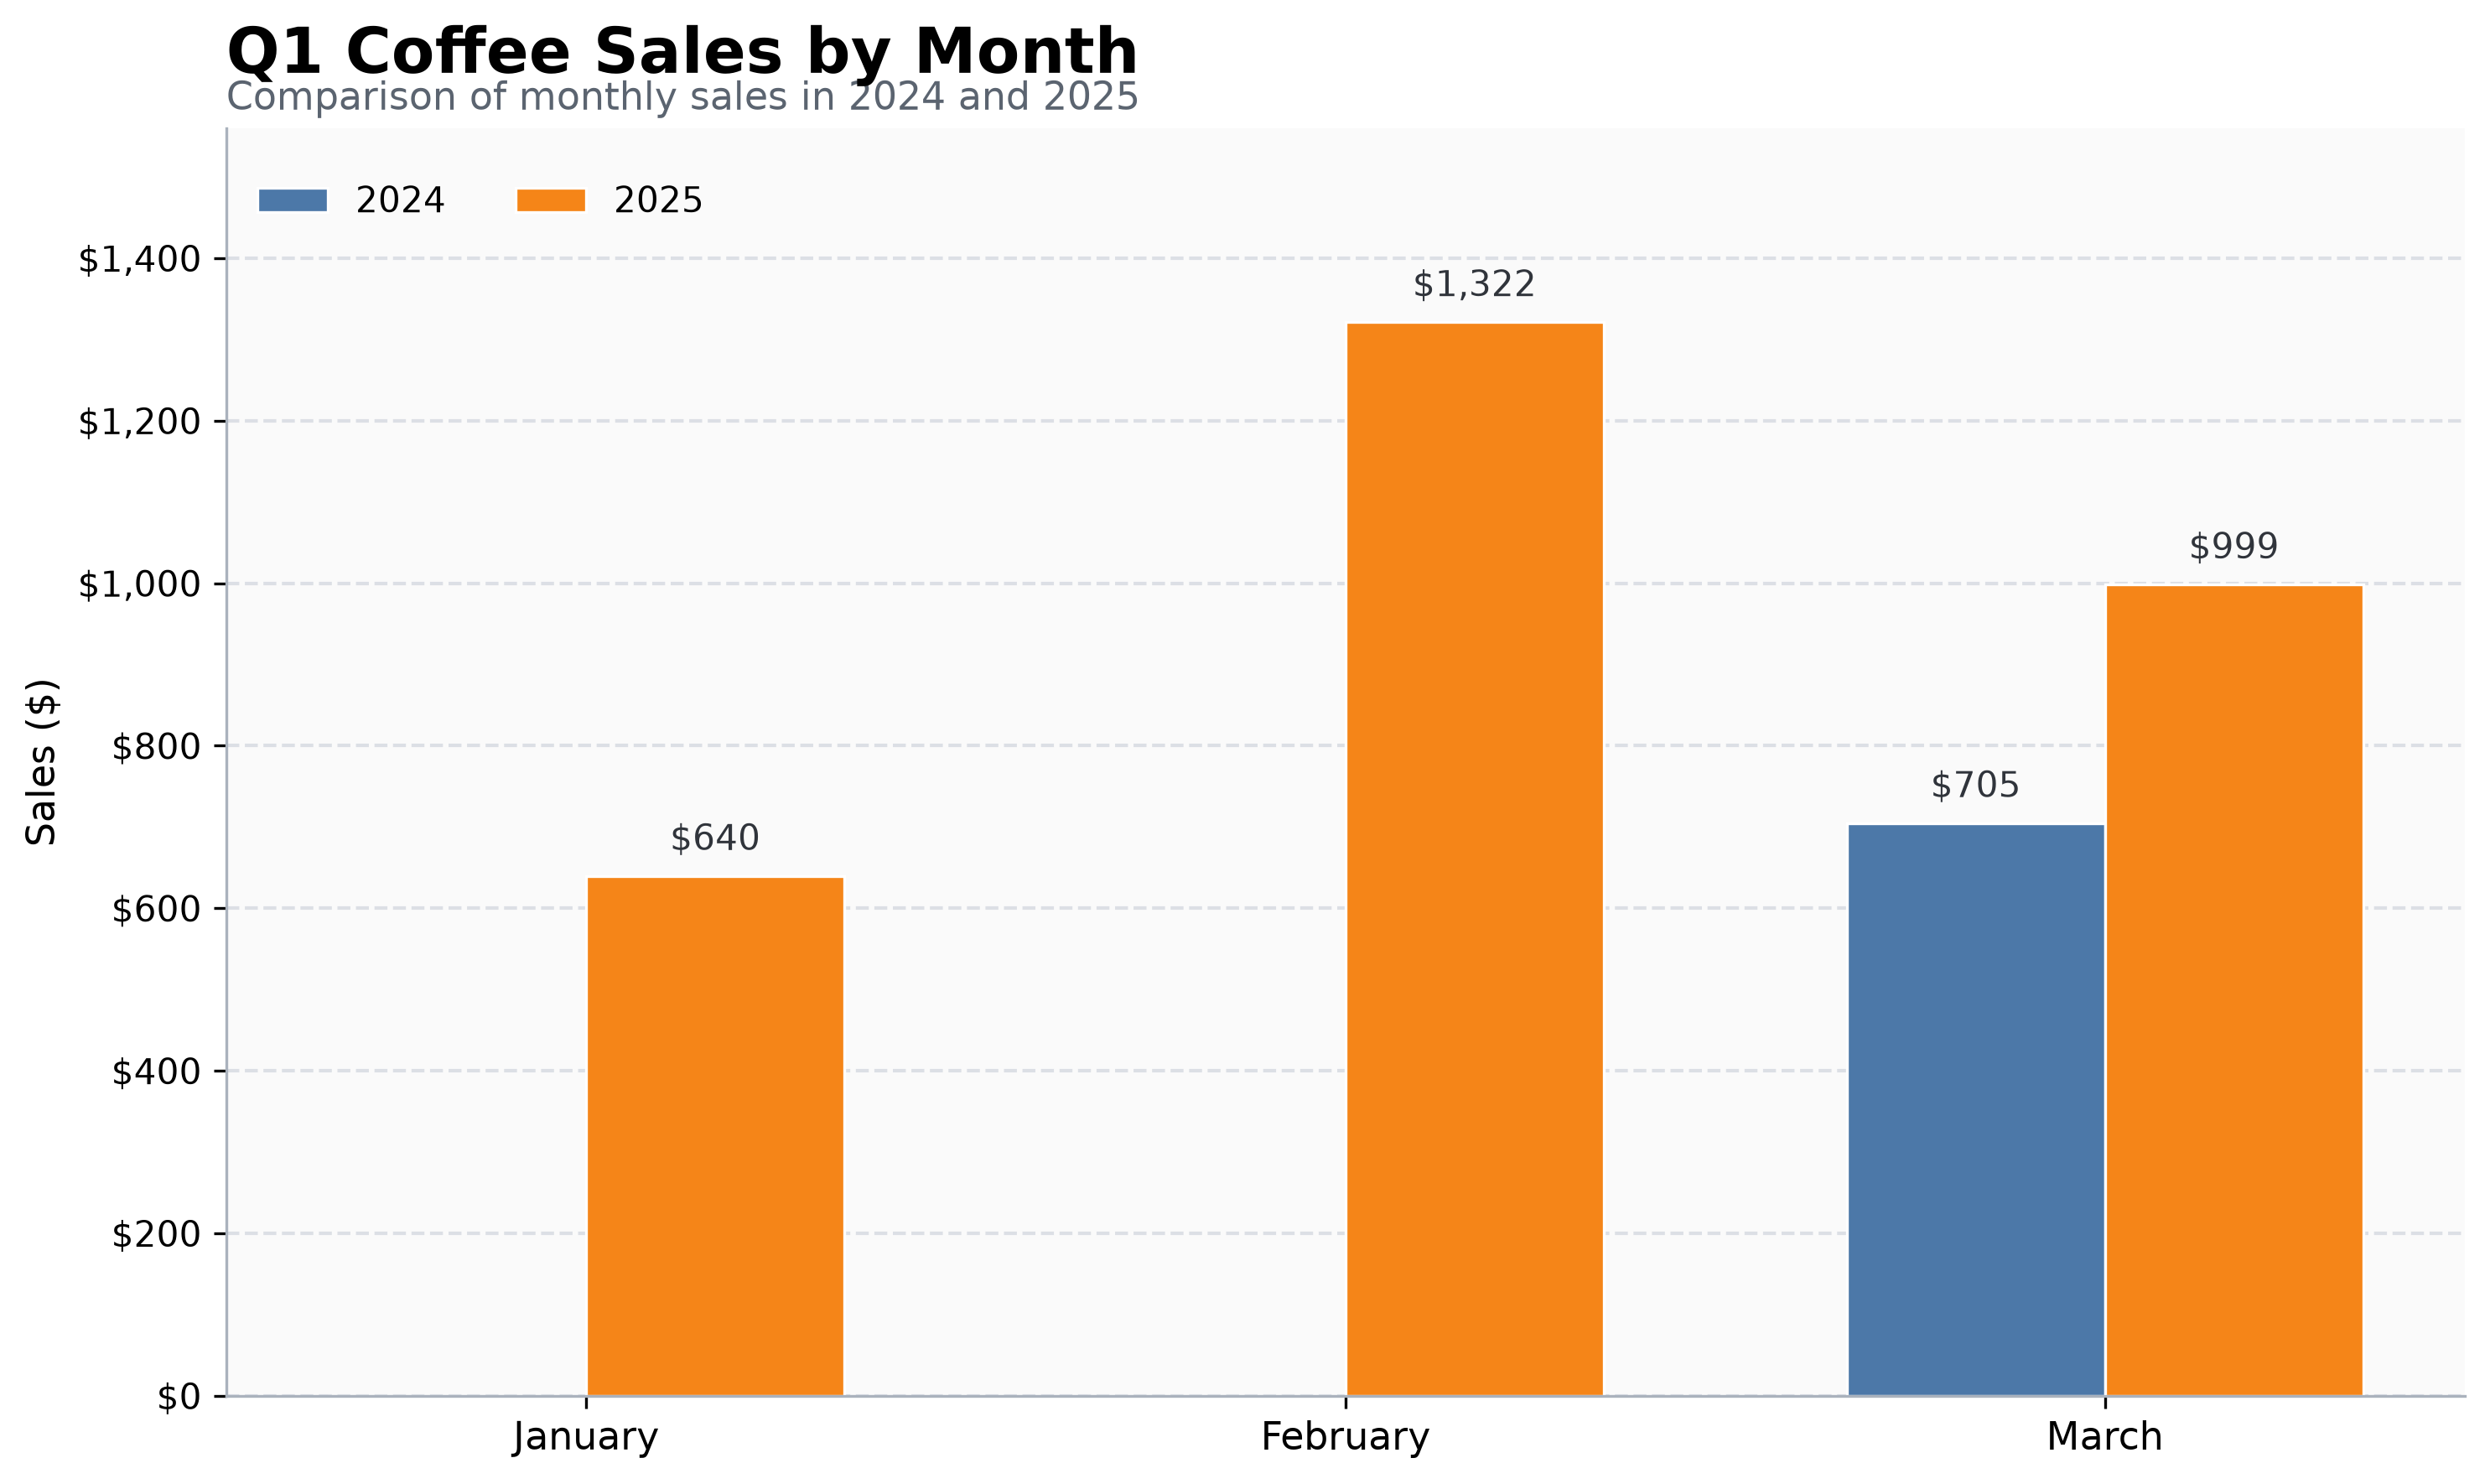

In [10]:
# Get the code within the <execute_python> tags
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
if match:
    reflected_code = match.group(1).strip()
    exec_globals = {"df": df}
    exec(reflected_code, exec_globals)

# If code run successfully, the file chart_v2.png should have been generated
utils.print_html(
    content="chart_v2.png",
    title="Regenerated Chart (V2)",
    is_image=True
)

In [11]:
def run_workflow(
        dataset_path: str,
        user_instructions: str,
        generation_model: str,
        reflection_model: str,
        image_basename: str = "chart",
):
    """
    End-to-end pipeline:
      1) load dataset
      2) generate V1 code
      3) execute V1 → produce chart_v1.png
      4) reflect on V1 (image + original code) → feedback + refined code
      5) execute V2 → produce chart_v2.png

    Returns a dict with all artifacts (codes, feedback, image paths).
    """
    # 0) Load dataset; utils handles parsing and feature derivations (e.g., year/quarter)
    df = utils.load_and_prepare_data(dataset_path)
    utils.print_html(df.sample(n=5), title="Random Sample of Dataset")

    # Paths to store charts
    out_v1 = f"{image_basename}_v1.png"
    out_v2 = f"{image_basename}_v2.png"

    # 1) Generate code (V1)
    utils.print_html("Step 1: Generating chart code (V1)… 📈")
    code_v1 = generate_chart_code(
        instruction=user_instructions,
        model=generation_model,
        out_path_v1=out_v1,
    )
    utils.print_html(code_v1, title="LLM output with first draft code (V1)")

    # 2) Execute V1 (hard-coded: extract <execute_python> block and run immediately)
    utils.print_html("Step 2: Executing chart code (V1)… 💻")
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
    if match:
        initial_code = match.group(1).strip()
        exec_globals = {"df": df}
        exec(initial_code, exec_globals)
    utils.print_html(out_v1, is_image=True, title="Generated Chart (V1)")

    # 3) Reflect on V1 (image + original code) to get feedback and refined code (V2)
    utils.print_html("Step 3: Reflecting on V1 (image + code) and generating improvements… 🔁")
    feedback, code_v2 = reflect_on_image_and_regenerate(
        chart_path=out_v1,
        instruction=user_instructions,
        model_name=reflection_model,
        out_path_v2=out_v2,
        code_v1=code_v1,  # pass original code for context
    )
    utils.print_html(feedback, title="Reflection feedback on V1")
    utils.print_html(code_v2, title="LLM output with revised code (V2)")

    # 4) Execute V2 (hard-coded: extract <execute_python> block and run immediately)
    utils.print_html("Step 4: Executing refined chart code (V2)… 🖼️")
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
    if match:
        reflected_code = match.group(1).strip()
        exec_globals = {"df": df}
        exec(reflected_code, exec_globals)
    utils.print_html(out_v2, is_image=True, title="Regenerated Chart (V2)")

    return {
        "code_v1": code_v1,
        "chart_v1": out_v1,
        "feedback": feedback,
        "code_v2": code_v2,
        "chart_v2": out_v2,
    }


date,time,cash_type,card,price,coffee_name,quarter,month,year
2024-11-12,06:08,card,ANON-0000-0000-0890,3.576,Latte,4,11,2024
2025-02-24,13:22,card,ANON-0000-0000-1222,3.086,Americano with Milk,1,2,2025
2024-03-05,17:19,card,ANON-0000-0000-0028,2.890,Cortado,1,3,2024
2024-03-30,07:39,card,ANON-0000-0000-0017,3.870,Latte,1,3,2024
2025-02-19,06:12,card,ANON-0000-0000-1161,3.576,Cappuccino,1,2,2025



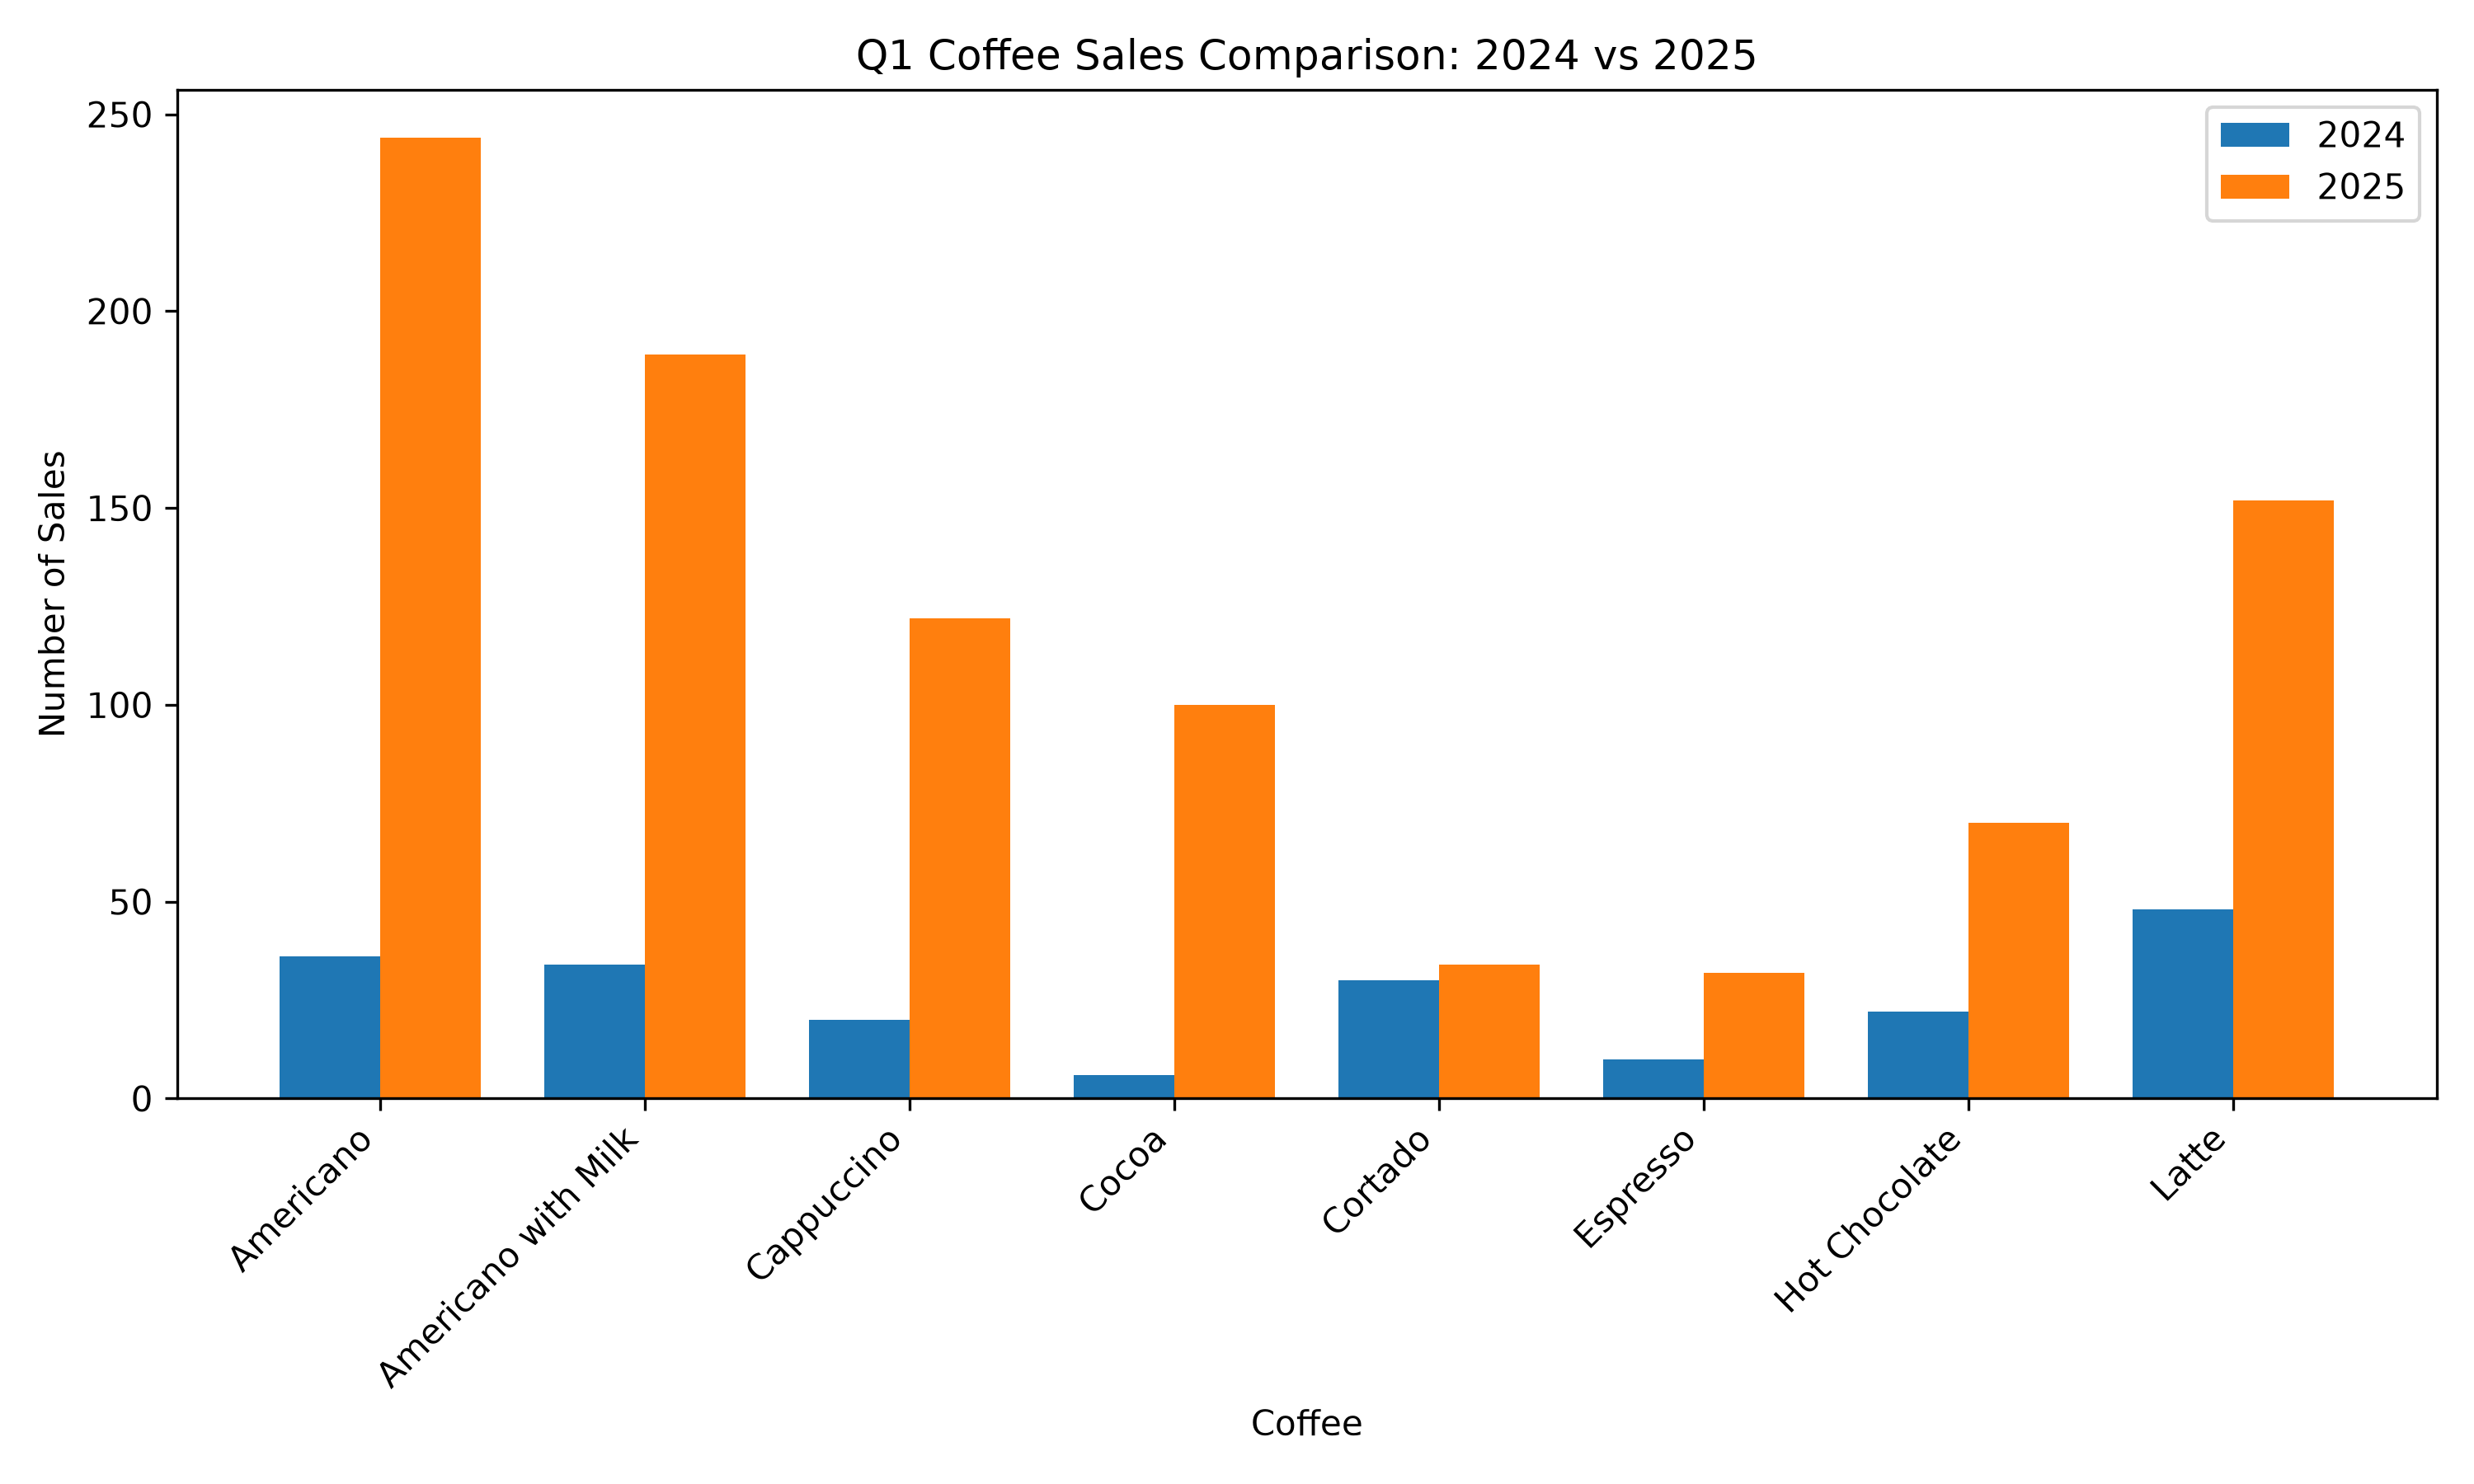


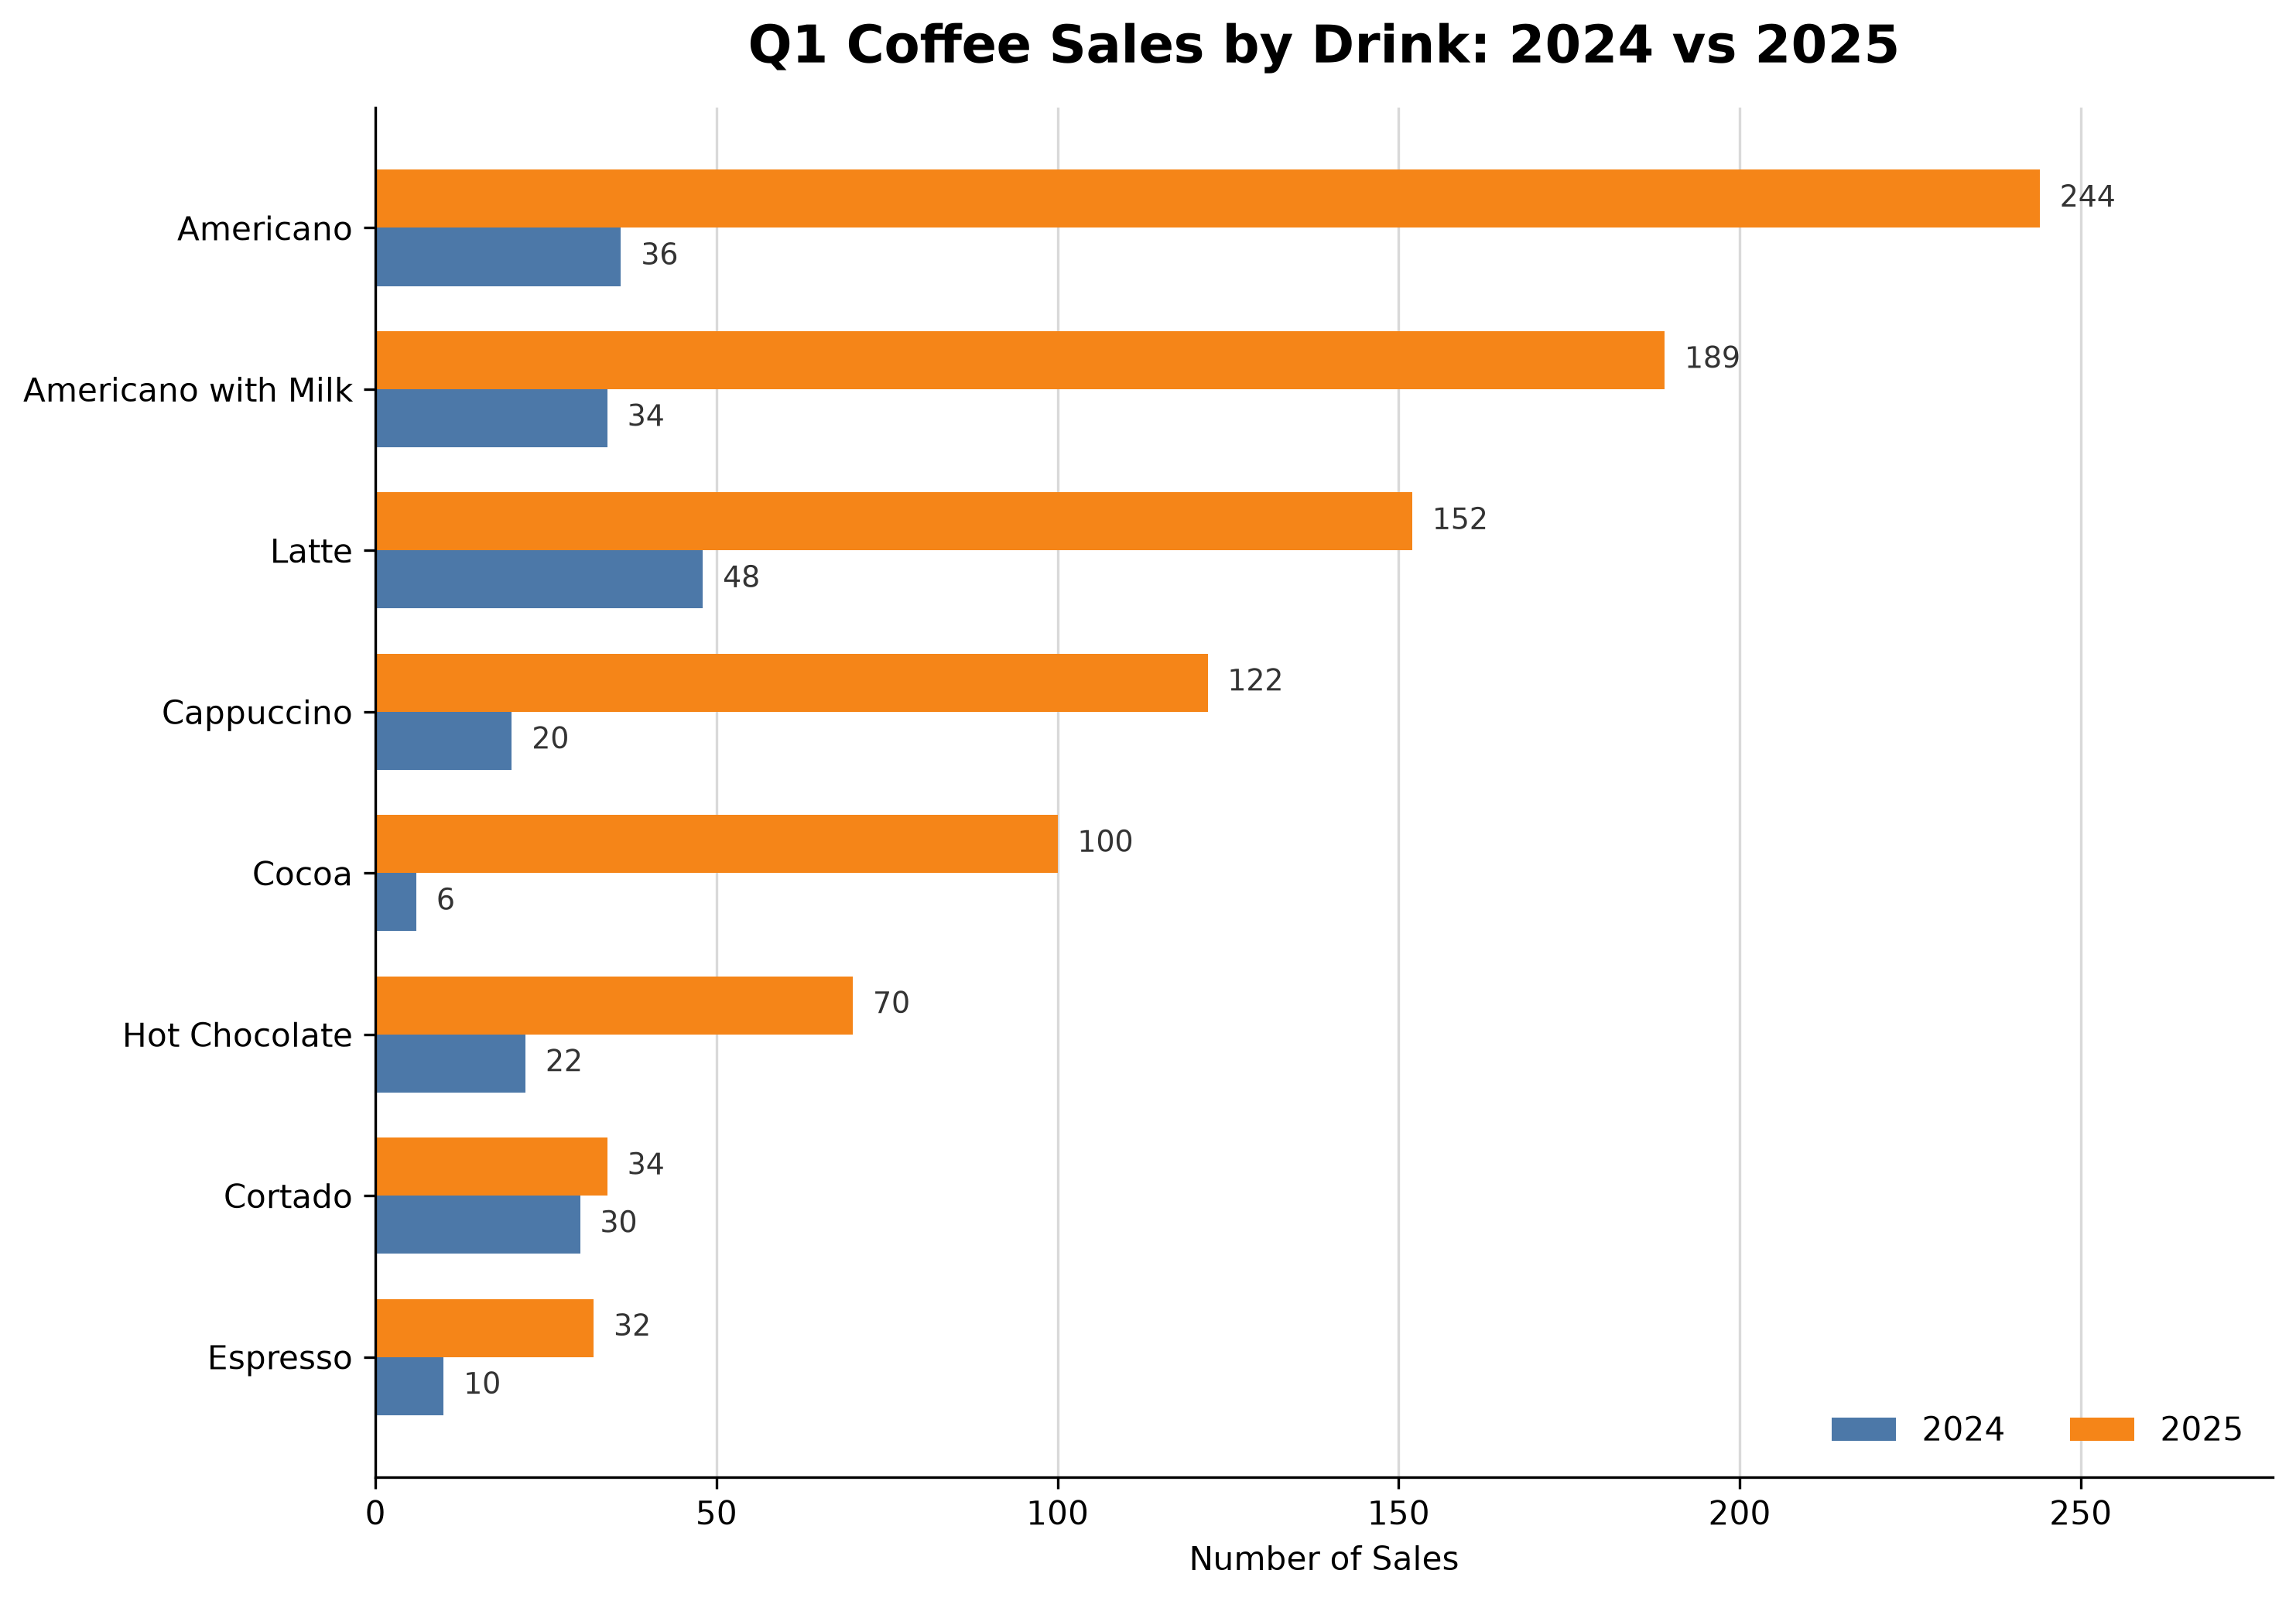

In [12]:
# Here, insert your updates
user_instructions = "Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv."  # write your instruction here
generation_model = "gpt-5.6-luna"
reflection_model = "gpt-5.6-terra"
# reflection_model="gpt-4.1"   # alternative reflection model
image_basename = "drink_sales"

# Run the complete agentic workflow
_ = run_workflow(
    dataset_path="coffee_sales.csv",
    user_instructions=user_instructions,
    generation_model=generation_model,
    reflection_model=reflection_model,
    image_basename=image_basename
)